**IMPORTING LIBRARIES**

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime 
import calendar

**LOADING DATESET**

In [19]:
df=pd.read_csv('Uber_Drives.csv')

In [20]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [21]:
df.shape

(1156, 7)

In [22]:
df.isnull().sum()

START_DATE*      0
END_DATE*        1
CATEGORY*        1
START*           1
STOP*            1
MILES*           0
PURPOSE*       503
dtype: int64

In [23]:
df=df.dropna()

In [24]:
df.shape

(653, 7)

In [25]:
df.dtypes

START_DATE*     object
END_DATE*       object
CATEGORY*       object
START*          object
STOP*           object
MILES*         float64
PURPOSE*        object
dtype: object

In [26]:
#changing data type from 'object' to datetime
df['START_DATE*']=pd.to_datetime(df['START_DATE*'], format='%m/%d/%Y %H:%M')
df['END_DATE*']=pd.to_datetime(df['END_DATE*'], format= '%m/%d/%Y %H:%M')

In [27]:
df.dtypes

START_DATE*    datetime64[ns]
END_DATE*      datetime64[ns]
CATEGORY*              object
START*                 object
STOP*                  object
MILES*                float64
PURPOSE*               object
dtype: object

In [28]:
#extracting hour from start_time and e

In [29]:
hour=[]
day=[]
dayofweek=[]
month=[]
weekday=[]

for x in df['START_DATE*']:
     hour.append(x.hour)
     day.append(x.day)
     dayofweek.append(x.dayofweek)
     month.append(x.month)
     weekday.append(calendar.day_name[dayofweek[-1]])

#creating columns
df['Hour']=hour
df['Day']=day
df['Day_of_Week']=dayofweek
df['Month']=month
df['Week_Day']=weekday

In [30]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,Hour,Day,Day_of_Week,Month,Week_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,1,4,1,Friday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,2,5,1,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,5,1,1,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,6,2,1,Wednesday
5,2016-01-06 17:15:00,2016-01-06 17:19:00,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,17,6,2,1,Wednesday


EDA: EXPLORATORY DATA ANALYSIS

In [31]:
df.to_csv('cleaned_uber_data.csv')

df['CATEGORY*'].value_counts()

CATEGORY*
Business    647
Personal      6
Name: count, dtype: int64

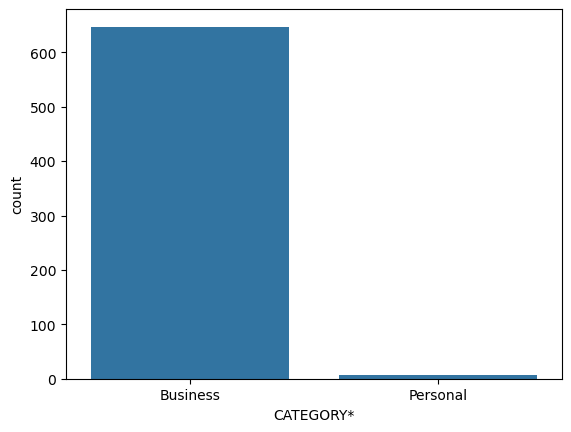

In [32]:
sns.countplot(x='CATEGORY*', data=df);

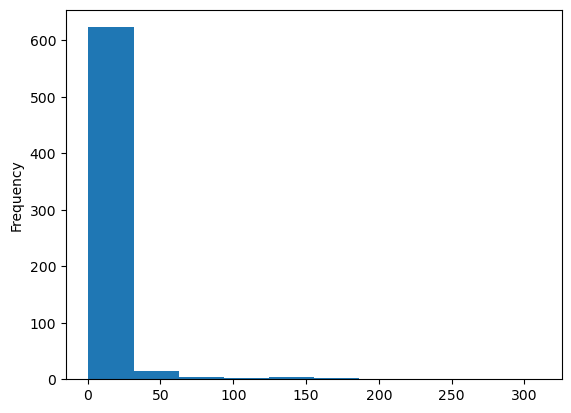

In [33]:
#OBJ 1: How long do people travel with uber

df['MILES*'].plot.hist();

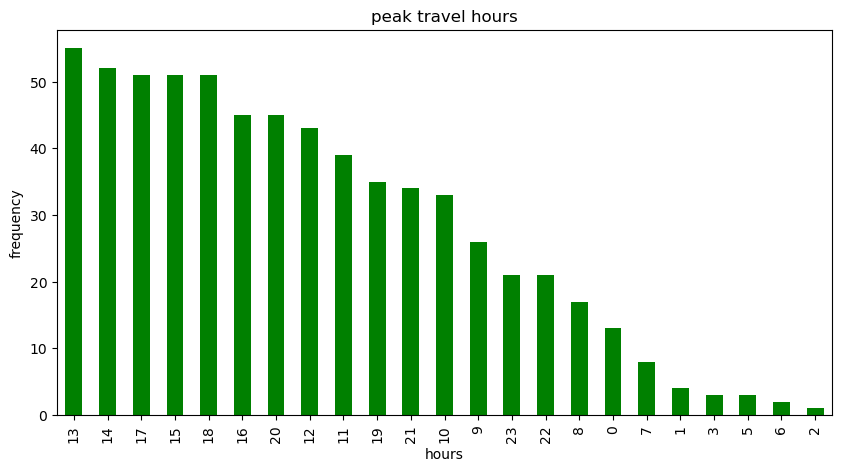

In [34]:
#OBJ 2: What hour do most people take uber to their destination
hours=df['START_DATE*'].dt.hour.value_counts()
hours.plot(kind='bar', color='green', figsize=(10,5))

plt.xlabel('hours')
plt.ylabel('frequency')
plt.title('peak travel hours')
plt.show()

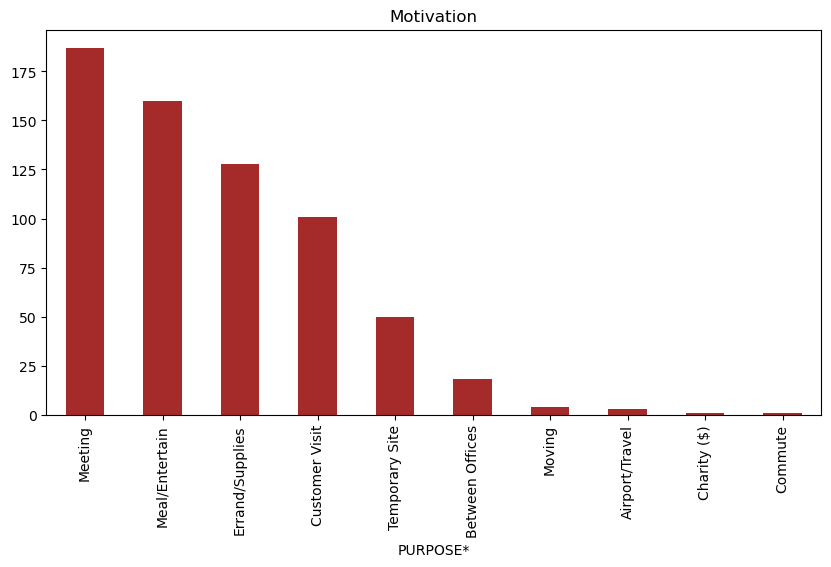

In [35]:
# OBJ 3: Chect the purpose of the trip

df['PURPOSE*'].value_counts().plot(kind='bar',color='brown', figsize=(10,5))
plt.title('Motivation');

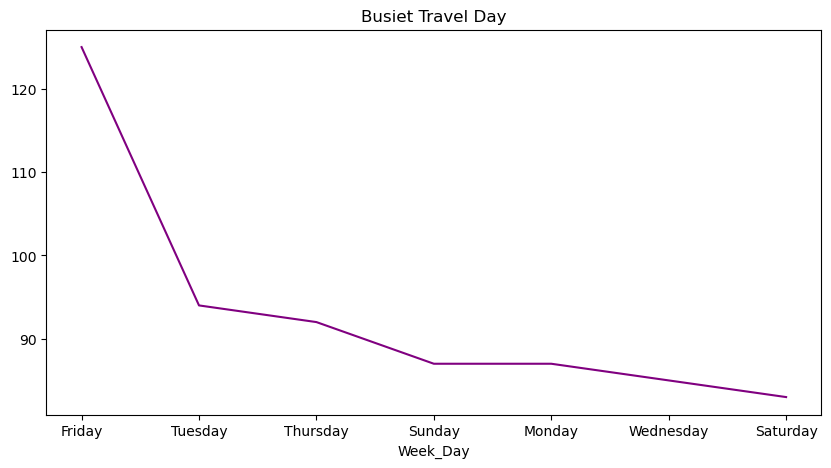

In [36]:
#OBJ 4: Which day has the highest number of trips

day=df['Week_Day'].value_counts()
day.plot(kind='line', color='purple', figsize=(10,5))
plt.title('Busiet Travel Day');

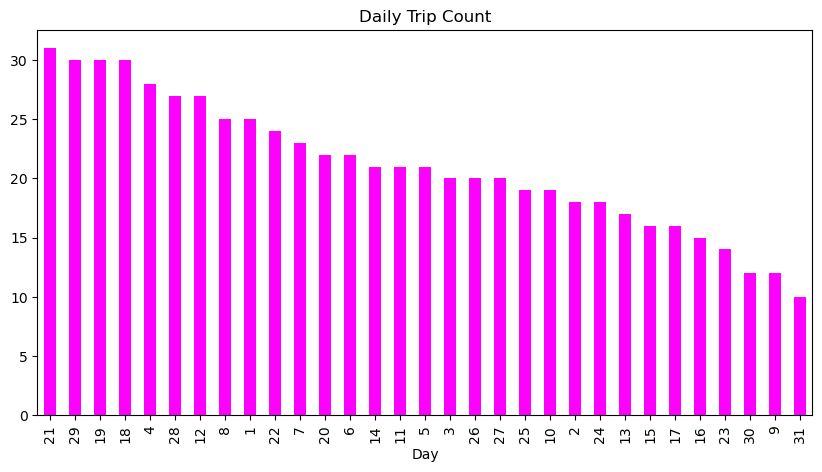

In [37]:
#OBJ 5: What are the number of trips per each day?

df['Day'].value_counts().plot(kind='bar', color='magenta', figsize=(10,5))
plt.title('Daily Trip Count');

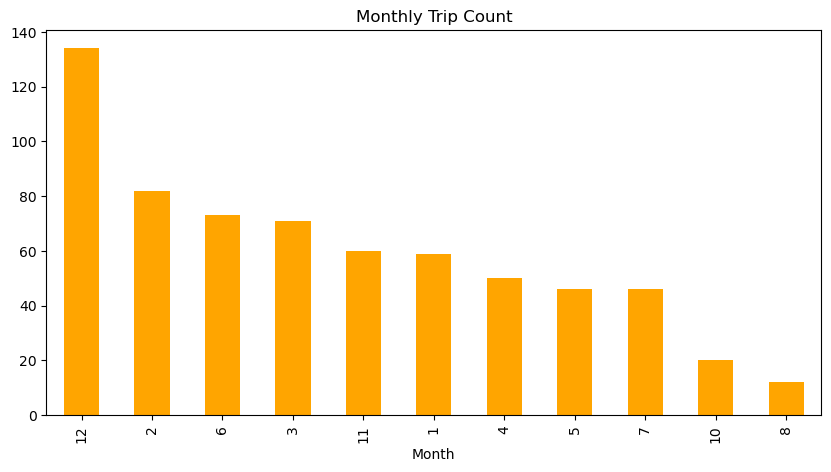

In [38]:
#OBJ 6: What are the trips a month?

df['Month'].value_counts().plot(kind='bar', color='orange', figsize=(10,5))
plt.title('Monthly Trip Count');

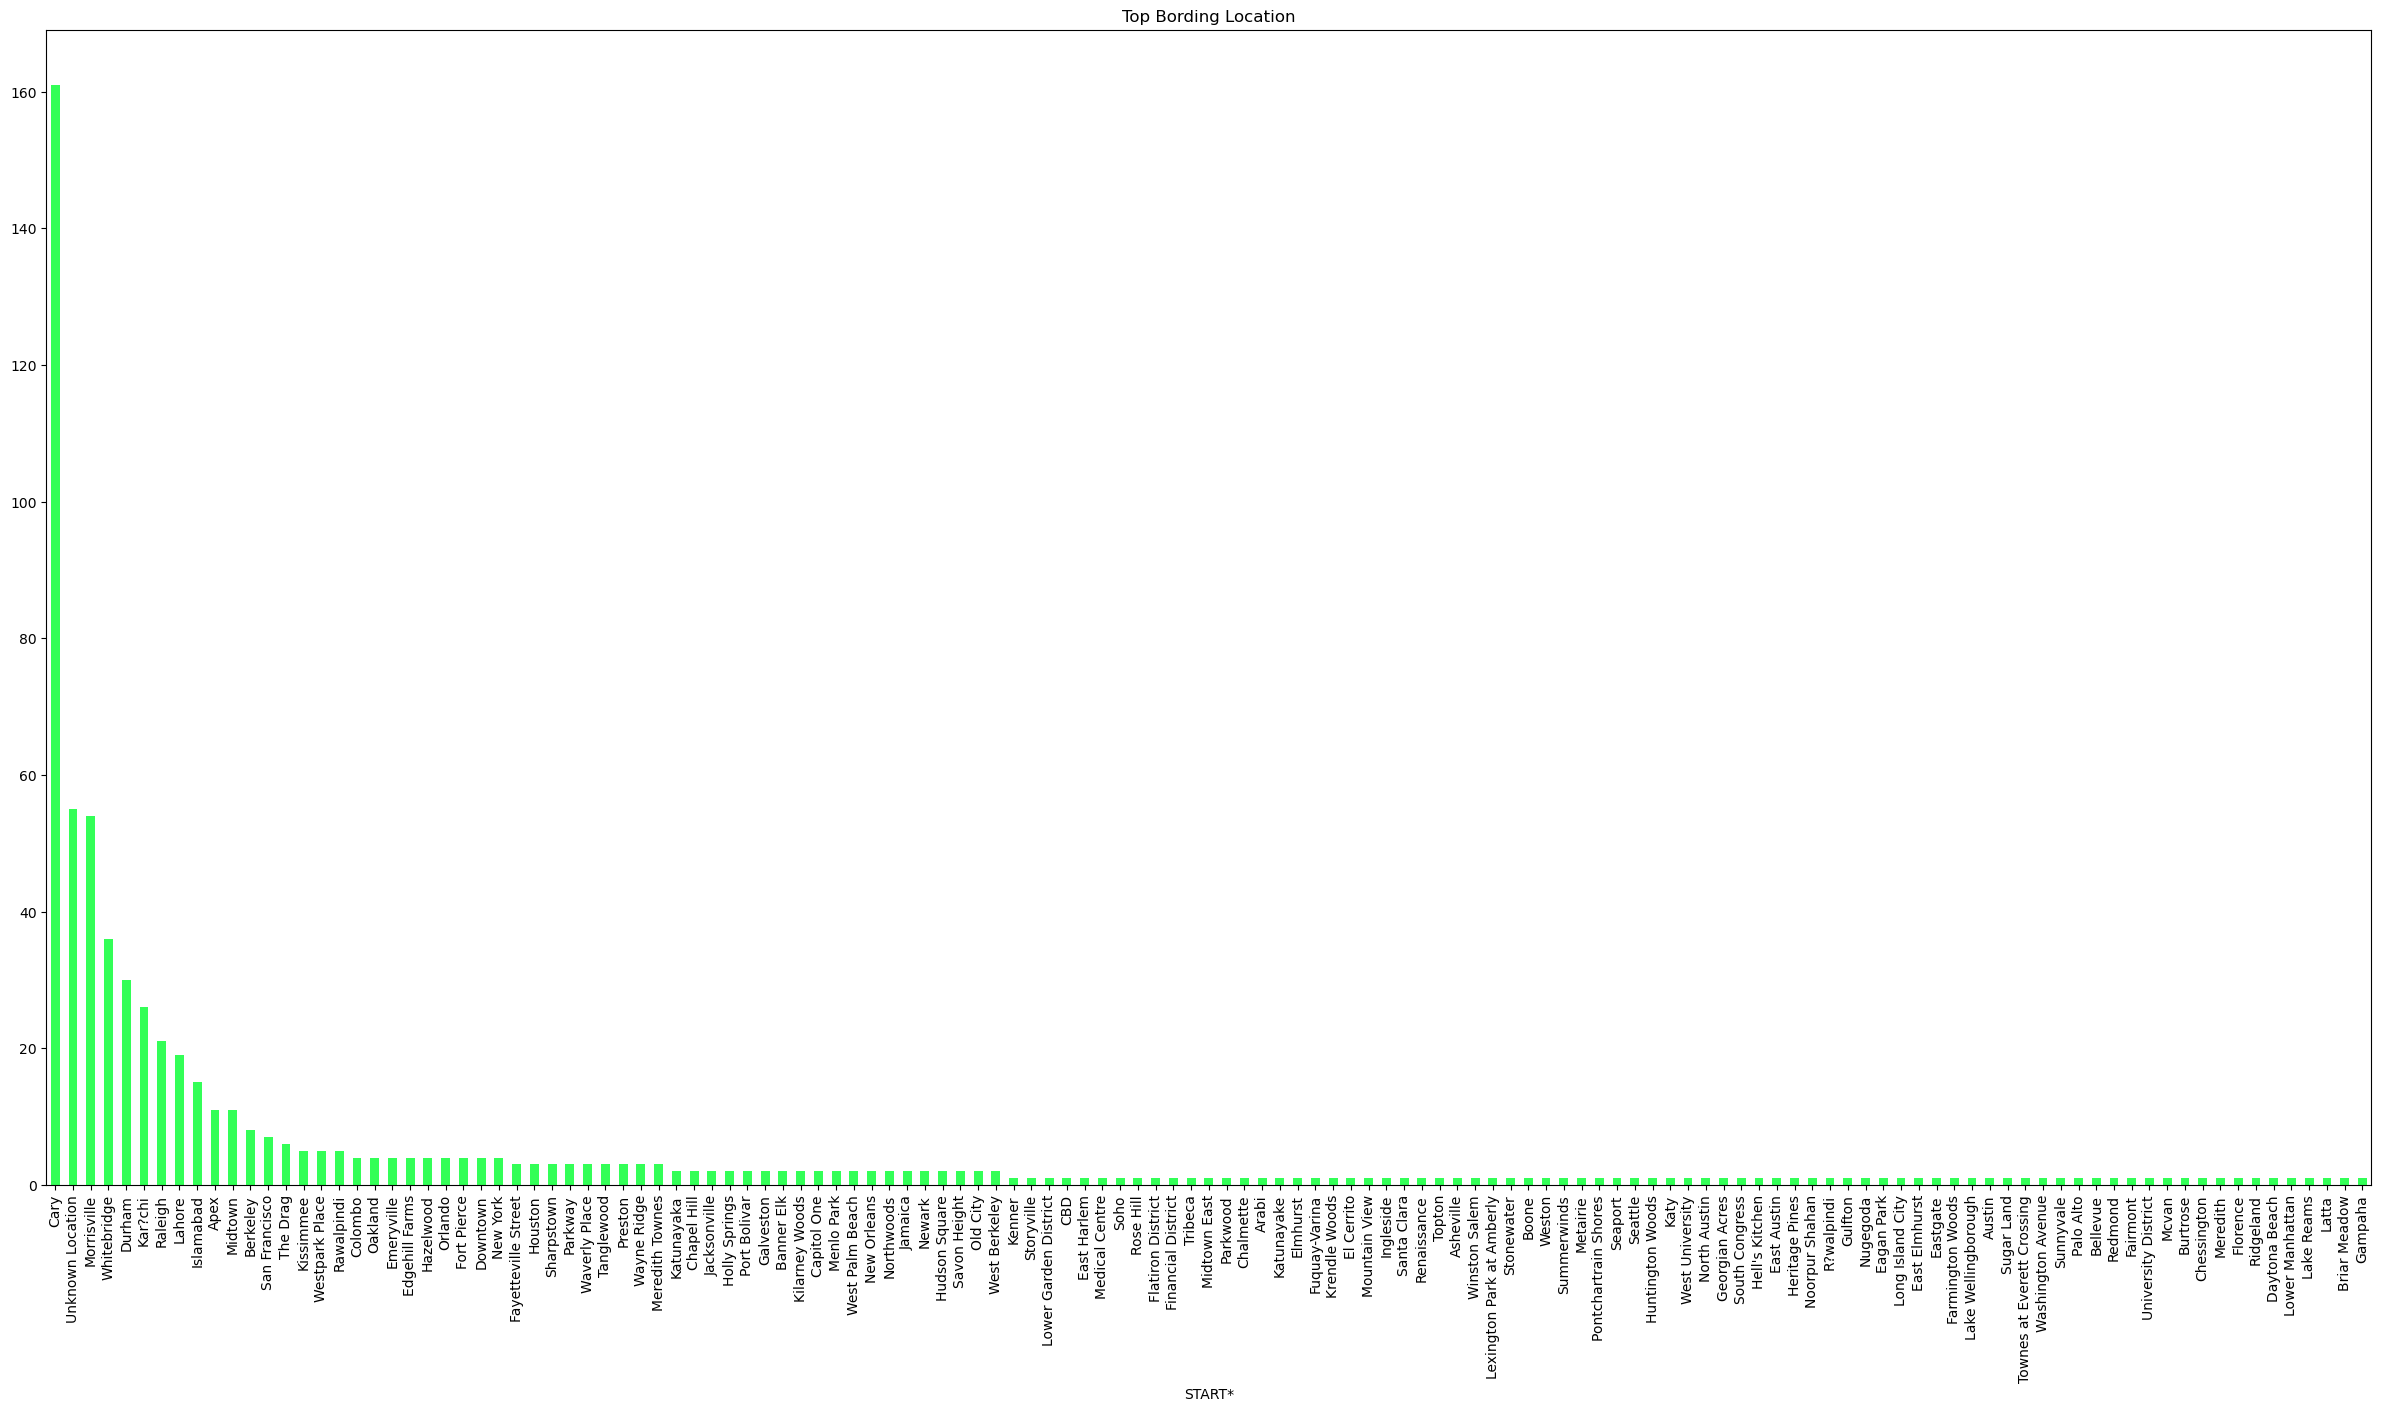

In [39]:
## OBJ 7:The starting point of trips. Where do people start bording their trip from the most?

df['START*'].value_counts().plot(kind='bar', color='#33FF57', figsize=(30,15))
plt.title('Top Bording Location');

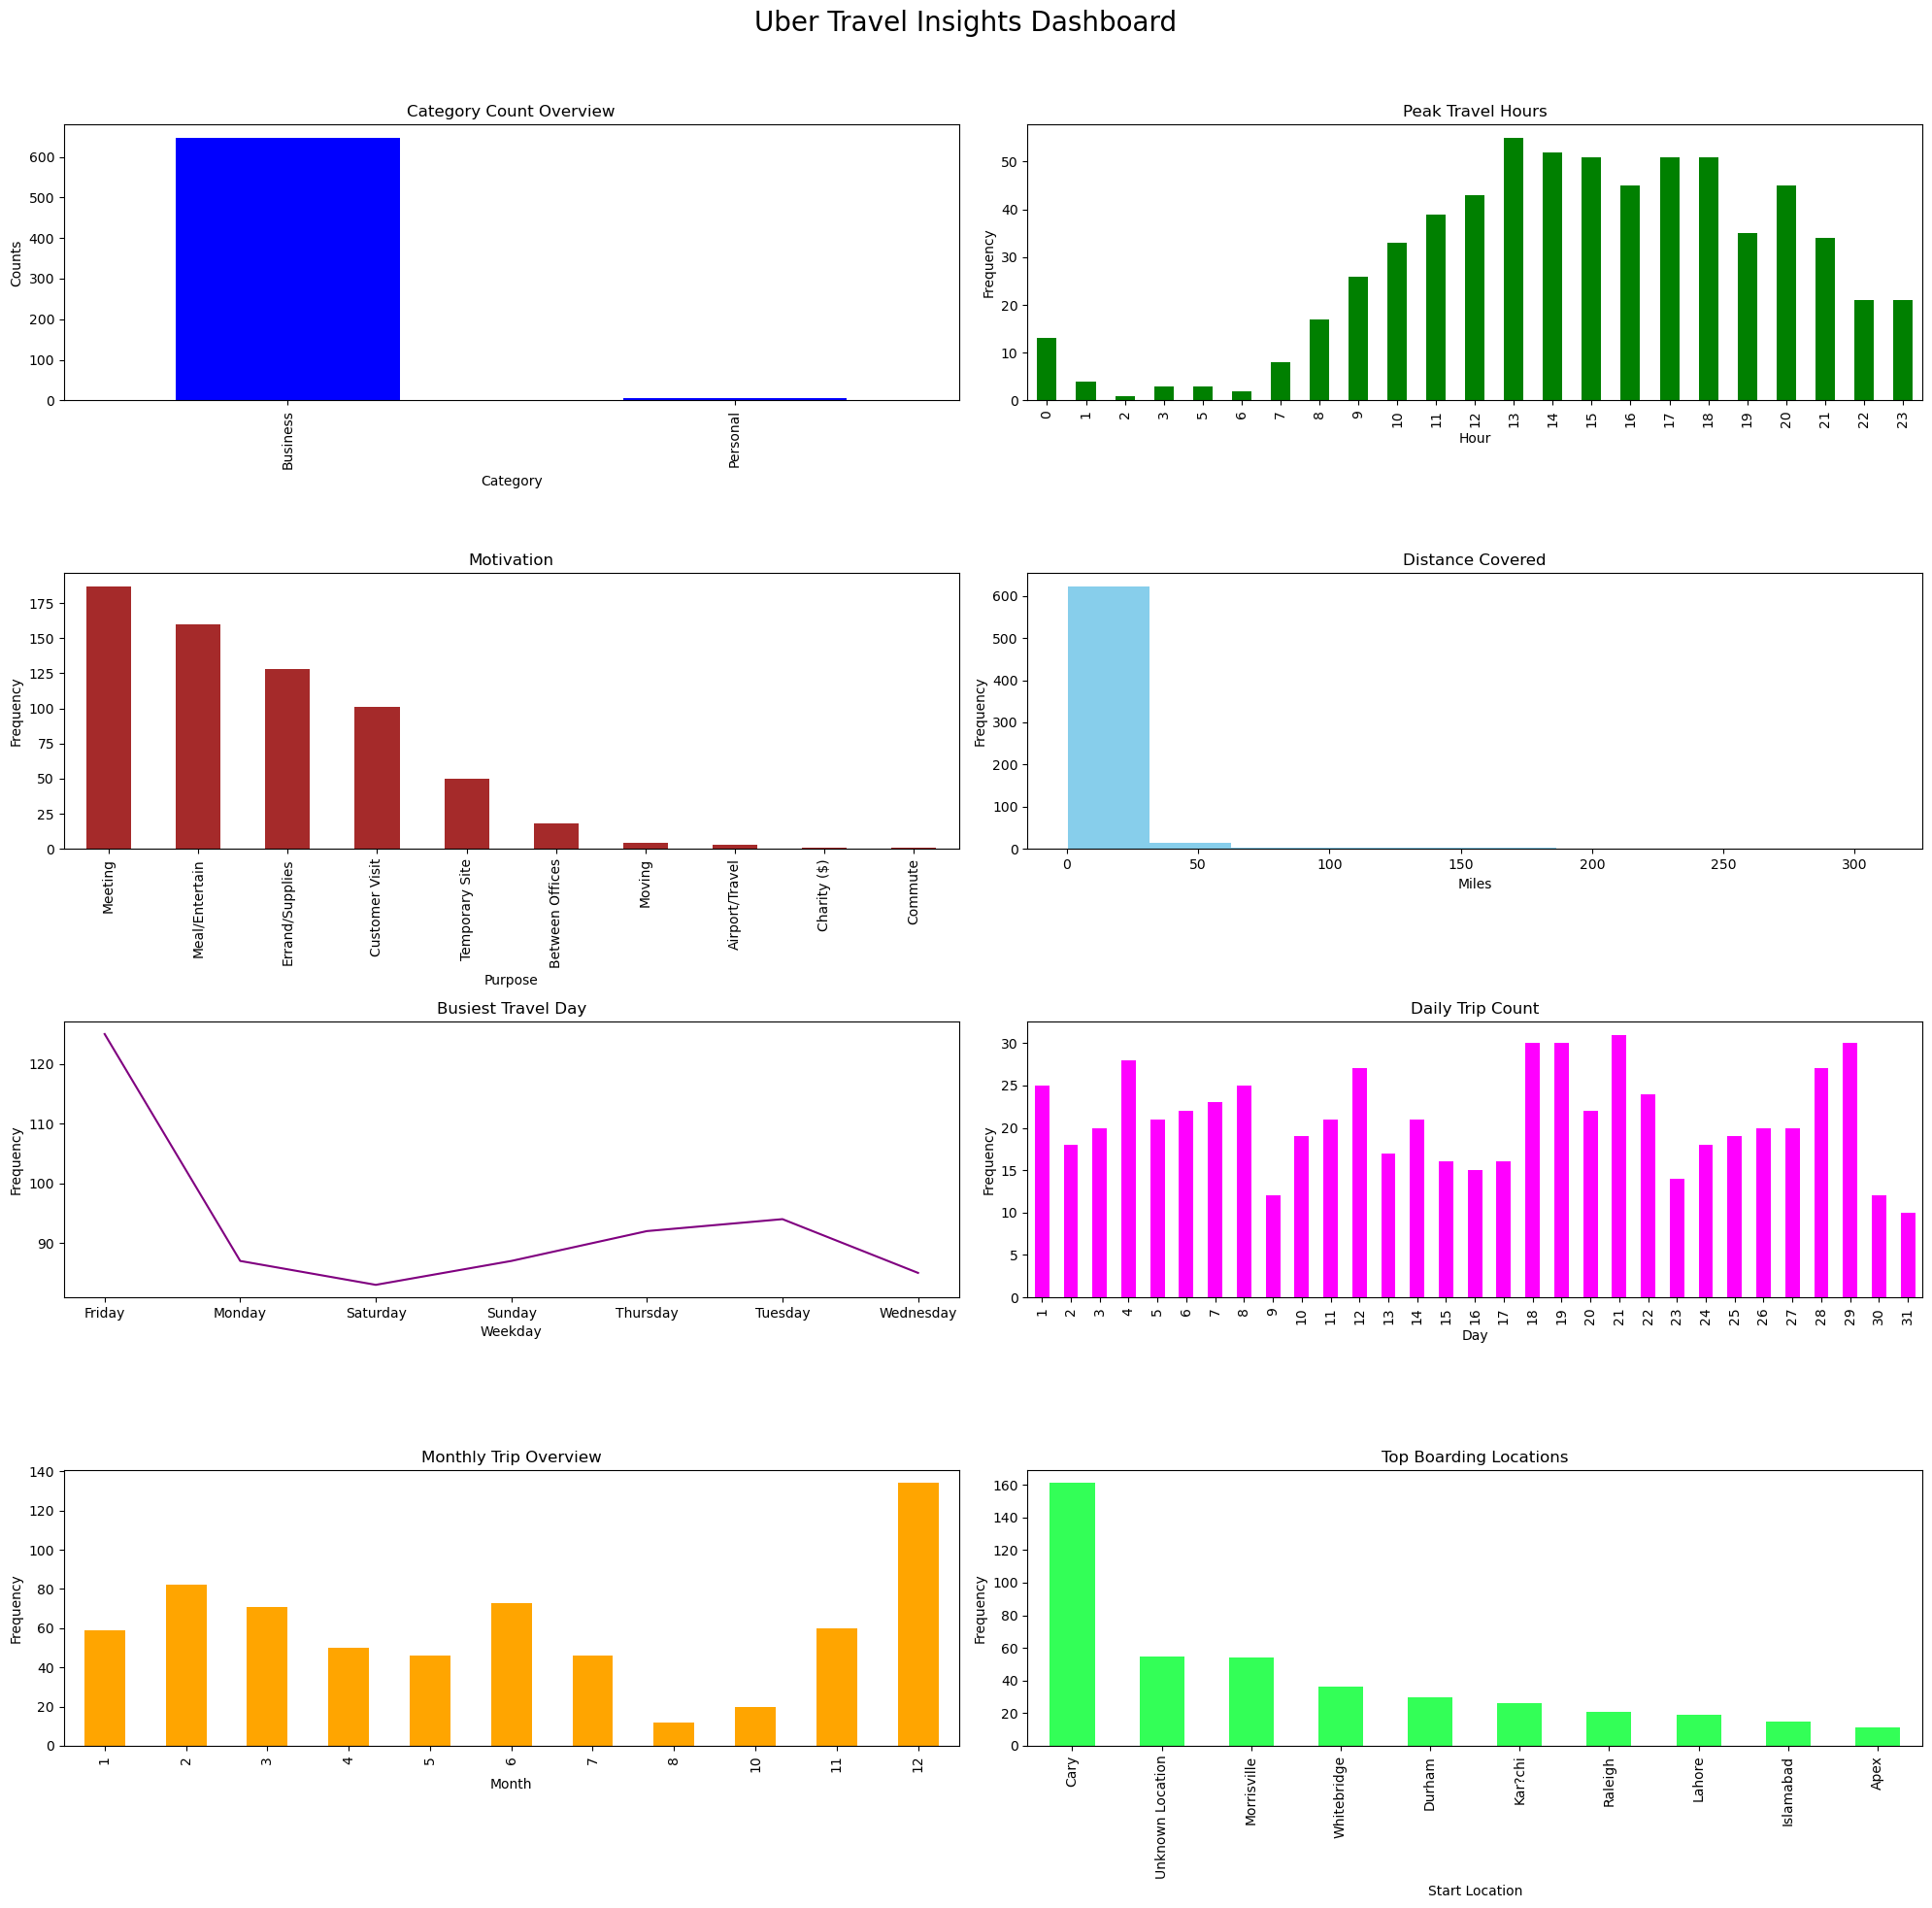

In [40]:
# Creating Python Dashboard

# Create subplots grid (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(20, 20))  
fig.suptitle('Uber Travel Insights Dashboard', fontsize=20)

# Plot 1: Category Count Overview
df['CATEGORY*'].value_counts().plot(kind='bar', color='blue', ax=axes[0, 0])
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Counts')
axes[0, 0].set_title("Category Count Overview")

# Plot 2: Peak Travel Hours
hours = df['START_DATE*'].dt.hour.value_counts().sort_index()  # Sort to ensure proper order
hours.plot(kind='bar', color='green', ax=axes[0, 1])
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Peak Travel Hours')

# Plot 3: Trip Purpose (Motivation)
df['PURPOSE*'].value_counts().plot(kind='bar', color='brown', ax=axes[1, 0])
axes[1, 0].set_xlabel('Purpose')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Motivation')

# Plot 4: Distance Covered (Miles)
df['MILES*'].plot(kind='hist', color='skyblue', ax=axes[1, 1])
axes[1, 1].set_xlabel('Miles')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title("Distance Covered")

# Plot 5: Busiest Travel Day
df['Week_Day'].value_counts().sort_index().plot(kind='line', color='purple', ax=axes[2, 0])
axes[2, 0].set_xlabel('Weekday')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title("Busiest Travel Day")

# Plot 6: Daily Trip Count
df['Day'].value_counts().sort_index().plot(kind='bar', color='magenta', ax=axes[2, 1])
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].set_title("Daily Trip Count")

# Plot 7: Monthly Trip Overview
df['Month'].value_counts().sort_index().plot(kind='bar', color='orange', ax=axes[3, 0])
axes[3, 0].set_xlabel('Month')
axes[3, 0].set_ylabel('Frequency')
axes[3, 0].set_title("Monthly Trip Overview")

# Plot 8: Top Boarding Location
df['START*'].value_counts().head(10).plot(kind='bar', color='#33FF57', ax=axes[3, 1])  # Show top 10 locations
axes[3, 1].set_xlabel('Start Location')
axes[3, 1].set_ylabel('Frequency')
axes[3, 1].set_title("Top Boarding Locations")

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig('Uber-Dashboard')
